In [10]:
from pathlib import Path
import os
import shutil
import zipfile

from urllib.request import urlretrieve

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# ========================================================
# 下載資料集
# ========================================================
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(exist_ok=True)

TIN_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
TIN_ZIP = DATA_ROOT / "tiny-imagenet-200.zip"
OUT_DIR = DATA_ROOT / "tiny-3class"

# class mapping: {wnid: (class_name, max_images)}
CLASS_INFO = {
    "n02099712": ("Labrador_Retriever", 400),
    "n02504458": ("African_Elephant", 400),
    "n01443537": ("Goldfish", 200),
}

# ========================================================
# Step 1 — Download tiny-imagenet zip
# ========================================================
if not OUT_DIR.exists():
    if not TIN_ZIP.exists():
        print("Downloading Tiny-ImageNet...")
        urlretrieve(TIN_URL, TIN_ZIP)
        print("Download complete.")
    else:
        print("Zip already exists.")
    
# ========================================================
# Step 2 — Selective extraction
# ========================================================

    print("\nExtracting ONLY selected categories...\n")

    with zipfile.ZipFile(TIN_ZIP, "r") as z:

        for wnid, (class_name, max_count) in CLASS_INFO.items():

            # output folder for images
            class_folder = OUT_DIR / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            prefix = f"tiny-imagenet-200/train/{wnid}/images/"
            img_files = sorted([
                f for f in z.namelist()
                if f.startswith(prefix) and f.lower().endswith(".jpeg")
            ])

            img_files = img_files[:max_count]  # limit number

            # extract limited images
            for f in img_files:
                z.extract(f, OUT_DIR)
                extracted = OUT_DIR / f
                # move to final location
                shutil.move(str(extracted), str(class_folder / Path(f).name))

            print(f"✔ {class_name}: {len(img_files)} images extracted")

            # remove intermediate tiny-imagenet-200 folder if exists
            temp_root = OUT_DIR / "tiny-imagenet-200"
            if temp_root.exists():
                shutil.rmtree(temp_root)
    print("\n Extraction complete!")
    print(f"Dataset ready at: {OUT_DIR}")

In [3]:
# ========================================================
# resized to 64 × 64
# ========================================================

# 1. 定義 transform：Resize + ToTensor + Normalize
#    Resize 到 64x64
transform = transforms.Compose([
    transforms.Resize((64, 64)),          # 題目要求的大小
    transforms.ToTensor(),                # 轉成 [0,1] tensor，形狀 C×H×W
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],       # 常用 ImageNet mean
        std=[0.229, 0.224, 0.225]         # 常用 ImageNet std
    ),
])

# 2. 用 ImageFolder 建立 Dataset
#   - root 底下每個子資料夾視為一個 class
#   - 我們現在是：tiny-3class/Labrador_Retriever/images/*.JPEG
#     ImageFolder 會遞迴往下找圖片，所以 OK
dataset = datasets.ImageFolder(
    root=str(OUT_DIR),
    transform=transform
)

# # 3. 看一下基本資訊
# print("Total samples:", len(dataset))
# print("Classes (folder name → label index):")
# print(dataset.class_to_idx)

# # 4. 建一個 DataLoader 測試一下
# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# # 取一個 batch 看形狀
# images, labels = next(iter(loader))
# print("Batch image shape:", images.shape)   # [32, 3, 64, 64]
# print("Batch labels:", labels[:10])

In [4]:
# ===== Train/Val split =====

# 設定隨機種子，確保每次 split 一樣（可重現）
torch.manual_seed(42)

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Total samples:", dataset_size)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# 建立 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 測試一個 batch
train_images, train_labels = next(iter(train_loader))
print("Train batch shape:", train_images.shape)
print("Train batch labels:", train_labels[:10])

Total samples: 1000
Train samples: 800
Val samples: 200
Train batch shape: torch.Size([32, 3, 64, 64])
Train batch labels: tensor([2, 2, 2, 0, 2, 2, 0, 0, 2, 2])


In [5]:
'''
CNN架構:捲積>池化>捲積>池化>捲積>池化>平坦層>全聯接層'''
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()

        # Convolution blocks
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        # After 3 maxpools → 64 × 8 × 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)   # latent feature (128-D)
        self.fc2 = nn.Linear(128, 3)            # 3 classes

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        # Block 2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        # Block 3
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC layers
        latent = F.relu(self.fc1(x))
        out = self.fc2(latent)

        return out, latent

In [6]:
# =======================
# Training model
# =======================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs, _ = model(images)
        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # 不需要計算梯度 → 加速 & 省顯存
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(val_loader), correct / total


# =======================
# Training entire model
# =======================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    return history


In [8]:
def plot_learning_curves(history):
    epochs = len(history["train_loss"])

    plt.figure(figsize=(14,5))

    # ----- Loss -----
    plt.subplot(1,2,1)
    plt.plot(range(epochs), history["train_loss"], label="Train Loss")
    plt.plot(range(epochs), history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)

    # ----- Accuracy -----
    plt.subplot(1,2,2)
    plt.plot(range(epochs), history["train_acc"], label="Train Acc")
    plt.plot(range(epochs), history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)

    plt.show()


In [11]:
def plot_confusion_matrix(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


Epoch [1/20] Train Loss: 0.9869, Train Acc: 48.38% | Val Loss: 0.7941, Val Acc: 66.50%
Epoch [2/20] Train Loss: 0.7226, Train Acc: 67.88% | Val Loss: 0.5555, Val Acc: 74.50%
Epoch [3/20] Train Loss: 0.5558, Train Acc: 77.38% | Val Loss: 0.5447, Val Acc: 74.50%
Epoch [4/20] Train Loss: 0.4696, Train Acc: 80.75% | Val Loss: 0.6092, Val Acc: 71.00%
Epoch [5/20] Train Loss: 0.4375, Train Acc: 83.12% | Val Loss: 0.5005, Val Acc: 79.00%
Epoch [6/20] Train Loss: 0.3632, Train Acc: 85.62% | Val Loss: 0.5942, Val Acc: 77.00%
Epoch [7/20] Train Loss: 0.3758, Train Acc: 84.50% | Val Loss: 0.5424, Val Acc: 77.00%
Epoch [8/20] Train Loss: 0.2998, Train Acc: 88.12% | Val Loss: 0.4646, Val Acc: 79.50%
Epoch [9/20] Train Loss: 0.2133, Train Acc: 92.75% | Val Loss: 0.5817, Val Acc: 79.50%
Epoch [10/20] Train Loss: 0.2476, Train Acc: 90.50% | Val Loss: 0.5559, Val Acc: 77.00%
Epoch [11/20] Train Loss: 0.1893, Train Acc: 93.25% | Val Loss: 0.5634, Val Acc: 80.00%
Epoch [12/20] Train Loss: 0.1135, Train A

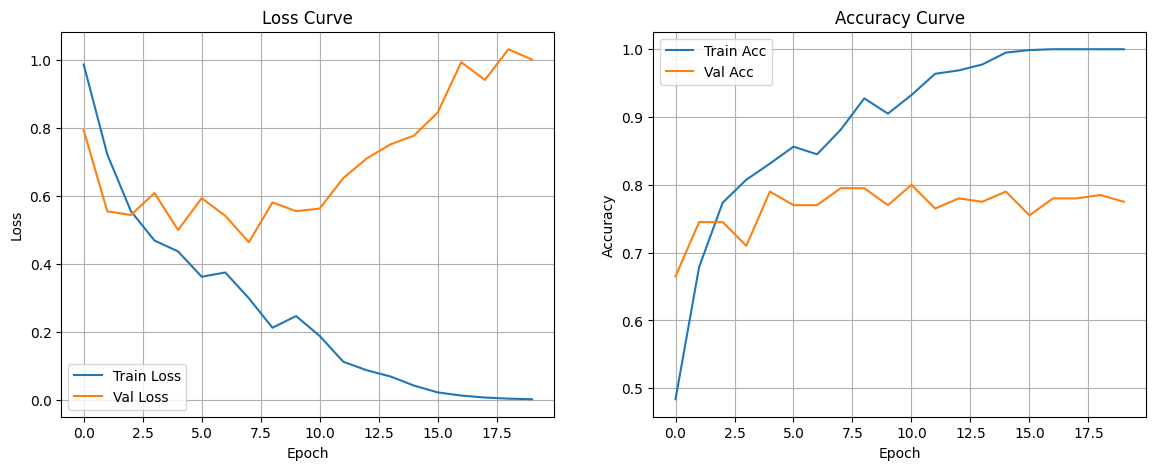

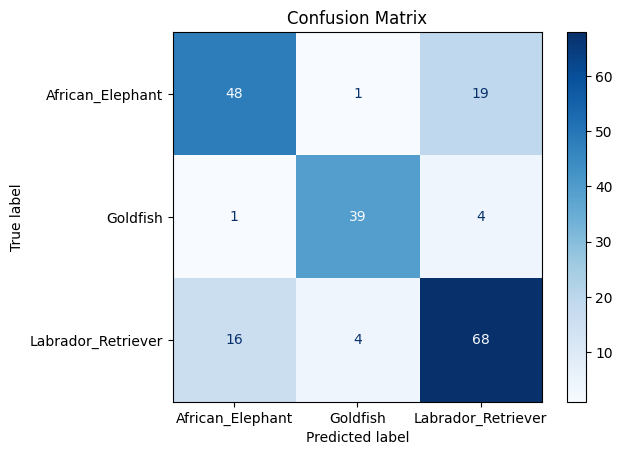

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20
)

plot_learning_curves(history)

plot_confusion_matrix(
    model,
    val_loader,
    device,
    class_names=list(dataset.class_to_idx.keys())
)
